c:\Users\akkus\miniconda3\envs\myconda\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\akkus\miniconda3\envs\myconda\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\akkus\miniconda3\envs\myconda\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\akkus\miniconda3\envs\myconda\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


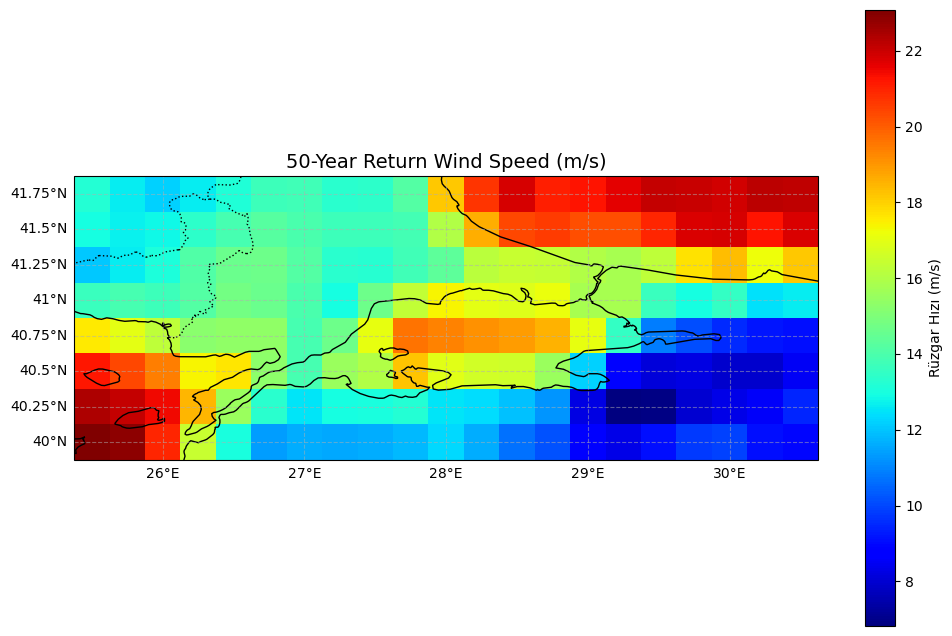

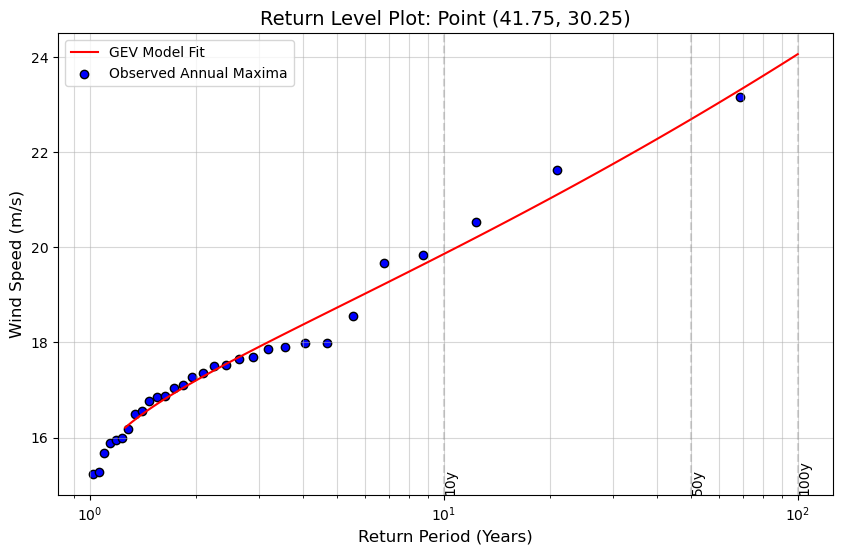

50 Yıllık Tahmin: 22.70 m/s
%95 Güven Aralığı: [20.34 - 27.43]
Seçilen noktadaki (41.75, 30.25) 30 yıllık maksimum rüzgar hızları çekildi.
En düşük yıllık maksimum: 15.23 m/s
En yüksek yıllık maksimum: 23.15 m/s


In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import genextreme
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs        
import cartopy.feature as cfeature

path = r"data\*.nc"
files = sorted(glob.glob(path))

ds_ref = xr.open_dataset(files[0], engine="netcdf4")
ref_lat = ds_ref.latitude
ref_lon = ds_ref.longitude
def align_to_ref(ds):
    if 'valid_time' in ds.coords:
        ds = ds.rename({'valid_time': 'time'})
    return ds.reindex(latitude=ref_lat, longitude=ref_lon, method='nearest')


ds = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim="time",
    preprocess=align_to_ref,
    coords="minimal",
    compat="override",
    join="override",
    engine="netcdf4"
)
monthly = ds.resample(time="1M").mean()
wind_speed = (ds["u10"]**2 + ds["v10"]**2)**0.5
wind_speed.name = "wind_speed"
monthly_ws = wind_speed.resample(time="1M").mean()
monthly_msl = ds["msl"].resample(time="1M").mean()
climatology = monthly.groupby("time.month").mean("time")
annual_max = wind_speed.resample(time="1Y").max()
mean = annual_max.mean("time")
std = annual_max.std("time")

beta = std * np.sqrt(6) / np.pi
mu = mean - 0.57721 * beta
T = 50
return_50 = mu - beta * np.log(-np.log(1 - 1/T))
threshold = 20

exceedance = (wind_speed > threshold)

freq_20 = exceedance.mean("time") * 100 
seasonal = wind_speed.groupby("time.season").mean("time")

seasonal_extreme = wind_speed.groupby("time.season").max("time")
risk_zone = (seasonal_extreme > 20)
freq_15 = (wind_speed > 15).mean("time") * 100
freq_12 = (wind_speed > 12).mean("time") * 100
lat_port = 40.9
lon_port = 29.0

port_ws = wind_speed.sel(latitude=lat_port, longitude=lon_port, method="nearest")

port_freq_20 = (port_ws > 20).mean().values * 100

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
return_50.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='jet', 
    cbar_kwargs={'label': 'Rüzgar Hızı (m/s)'}
)
ax.coastlines(resolution='10m', color='black', linewidth=1) 
ax.add_feature(cfeature.BORDERS, linestyle=':')             
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3) 

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False   
gl.right_labels = False 

plt.title(f"{T}-Year Return Wind Speed (m/s)", fontsize=14)
plt.show()

def calculate_return_level(data, return_period=50):
    data = data[~np.isnan(data)] 
    if len(data) < 30: 
        return np.nan
    try:
        
        shape, loc, scale = genextreme.fit(data)
       
        return_level = genextreme.ppf(1 - 1/return_period, shape, loc, scale)
        return return_level
    except:
        return np.nan
annual_max = annual_max.chunk(dict(time=-1))

rl50 = xr.apply_ufunc(
    calculate_return_level,
    annual_max,
    input_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

rl50_final = rl50.compute()
flat_idx = rl50_final.values.argmax()
idx_2d = np.unravel_index(flat_idx, rl50_final.shape)

max_val = rl50_final.values[idx_2d]
lat_max = rl50_final.latitude.values[idx_2d[0]]
lon_max = rl50_final.longitude.values[idx_2d[1]]

point_data = annual_max.sel(latitude=lat_max, longitude=lon_max).values
point_data = point_data[~np.isnan(point_data)] 
point_data.sort()


c, loc, scale = genextreme.fit(point_data)

return_periods = np.logspace(0.1, 2, 100) 
return_levels = genextreme.ppf(1 - 1/return_periods, c, loc=loc, scale=scale)

n = len(point_data)
ranks = np.arange(1, n + 1)
obs_return_periods = (n + 0.12) / (n - ranks + 0.44)

plt.figure(figsize=(10, 6))
plt.semilogx(return_periods, return_levels, 'r-', label='GEV Model Fit') 
plt.scatter(obs_return_periods, point_data, color='blue', edgecolor='k', label='Observed Annual Maxima')

plt.title(f"Return Level Plot: Point ({lat_max}, {lon_max})", fontsize=14)
plt.xlabel("Return Period (Years)", fontsize=12)
plt.ylabel("Wind Speed (m/s)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

for years in [10, 50, 100]:
    rl = genextreme.ppf(1 - 1/years, c, loc=loc, scale=scale)
    plt.axvline(years, color='gray', linestyle='--', alpha=0.3)
    plt.text(years, plt.ylim()[0], f'{years}y', rotation=90, verticalalignment='bottom')

plt.show()

n_bootstrap = 100  
boot_rls = []

for i in range(n_bootstrap):
    
    sample = np.random.choice(point_data, size=len(point_data), replace=True)
    try:
        c_b, loc_b, scale_b = genextreme.fit(sample)
        rl_50_b = genextreme.ppf(1 - 1/50, c_b, loc=loc_b, scale=scale_b)
        boot_rls.append(rl_50_b)
    except:
        continue

lower_ci = np.percentile(boot_rls, 2.5)
upper_ci = np.percentile(boot_rls, 97.5)

print(f"50 Yıllık Tahmin: {max_val:.2f} m/s")
print(f"%95 Güven Aralığı: [{lower_ci:.2f} - {upper_ci:.2f}]")

point_data = annual_max.sel(latitude=lat_max, longitude=lon_max).values

point_data = point_data[~np.isnan(point_data)]
point_data.sort() 

print(f"Seçilen noktadaki ({lat_max:.2f}, {lon_max:.2f}) 30 yıllık maksimum rüzgar hızları çekildi.")
print(f"En düşük yıllık maksimum: {point_data.min():.2f} m/s")
print(f"En yüksek yıllık maksimum: {point_data.max():.2f} m/s")
